<a href="https://colab.research.google.com/github/Ahmedkhairy-tech/Sales-Data-Analysis-Project-by-paython-/blob/main/Sales_Performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel('/content/01KA3ZF3978EEZWA02T8AAMEY3.xlsx')

In [4]:
df.shape

(2000, 10)

In [5]:
df.columns

Index(['date', 'units_sold', 'unit_price', 'cost', 'daily_revenue',
       'product_type', 'style', 'customer_segment', 'channel', 'ad_spend'],
      dtype='object')

In [6]:
df.head()

,date,units_sold,unit_price,cost,daily_revenue,product_type,style,customer_segment,channel,ad_spend
0,2023-08-12,8,49.73,22.30,397.84,Dress,Sport,Premium,Online,89.68
1,2023-01-05,2,146.41,80.10,292.82,Jacket,Casual,Budget,Online,77.60
2,2024-02-21,17,82.99,44.94,1410.83,Jacket,Sport,Mid,Online,56.39
3,2024-01-13,12,14.07,11.40,168.84,Dress,Formal,Premium,Online,58.14
4,2024-06-09,7,149.54,66.89,1046.78,Dress,Sport,Premium,In-store,20.71


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              2000 non-null   datetime64[ns]
 1   units_sold        2000 non-null   int64         
 2   unit_price        2000 non-null   float64       
 3   cost              2000 non-null   float64       
 4   daily_revenue     2000 non-null   float64       
 5   product_type      2000 non-null   object        
 6   style             2000 non-null   object        
 7   customer_segment  2000 non-null   object        
 8   channel           2000 non-null   object        
 9   ad_spend          2000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 156.4+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

,0
date,0
units_sold,0
unit_price,0
cost,0
daily_revenue,0
product_type,0
style,0
customer_segment,0
channel,0
ad_spend,0


In [10]:
df.tail()

,date,units_sold,unit_price,cost,daily_revenue,product_type,style,customer_segment,channel,ad_spend
1995,2023-12-30,5,49.28,24.67,246.40,Dress,Casual,Premium,In-store,69.94
1996,2023-08-14,10,37.98,19.47,379.80,Jacket,Casual,Budget,Online,86.22
1997,2024-10-16,17,36.46,19.53,619.82,Pants,Casual,Budget,Online,44.83
1998,2023-09-30,3,90.53,36.54,271.59,Jacket,Sport,Budget,Online,93.46
1999,2023-02-18,5,22.09,14.79,110.45,Jacket,Formal,Premium,In-store,96.69


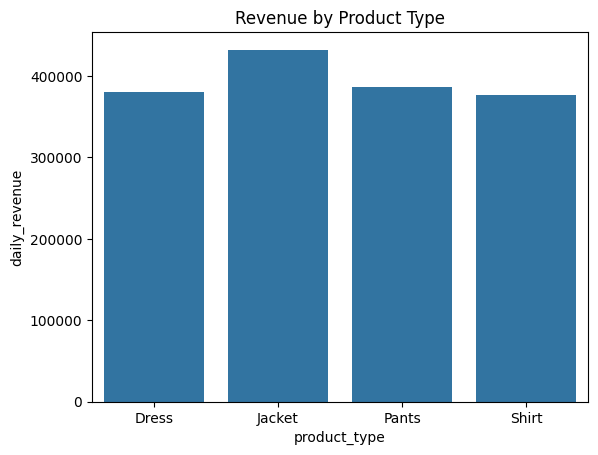

In [11]:

prod_rev = df.groupby('product_type')['daily_revenue'].sum().reset_index()
sns.barplot(data=prod_rev, x='product_type', y='daily_revenue')
plt.title("Revenue by Product Type")
plt.show()


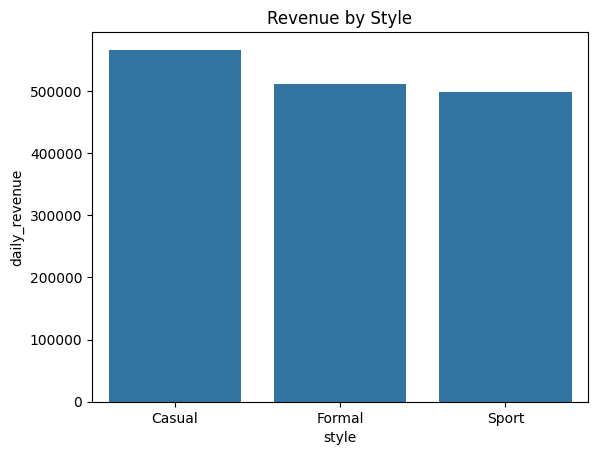

In [12]:
style_rev = df.groupby('style')['daily_revenue'].sum().reset_index()
sns.barplot(data=style_rev, x='style', y='daily_revenue')
plt.title("Revenue by Style")
plt.show()


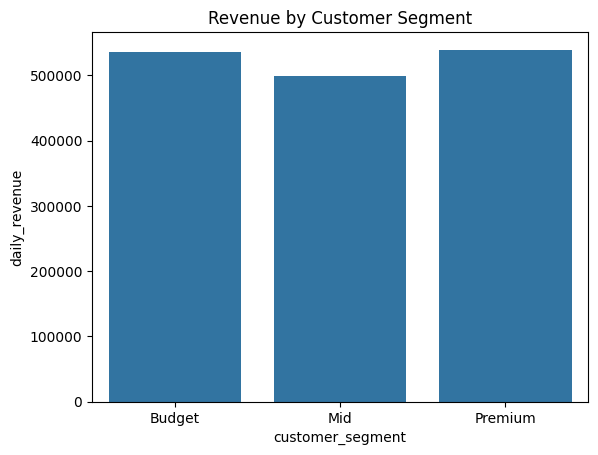

In [13]:
seg_rev = df.groupby('customer_segment')['daily_revenue'].sum().reset_index()
sns.barplot(data=seg_rev, x='customer_segment', y='daily_revenue')
plt.title("Revenue by Customer Segment")
plt.show()


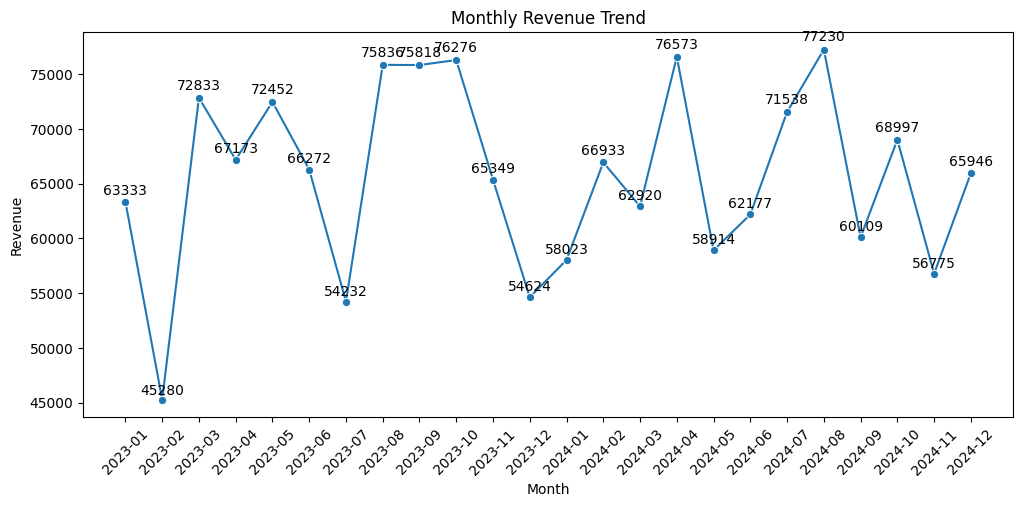

In [16]:

df['Month'] = df['date'].dt.to_period('M').astype(str)

monthly_rev = df.groupby('Month')['daily_revenue'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_rev, x='Month', y='daily_revenue', marker='o')

# إضافة القيم فوق النقاط
for i, row in monthly_rev.iterrows():
   plt.text(i, row['daily_revenue']+row['daily_revenue']*0.01, f"{row['daily_revenue']:.0f}", ha='center')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()



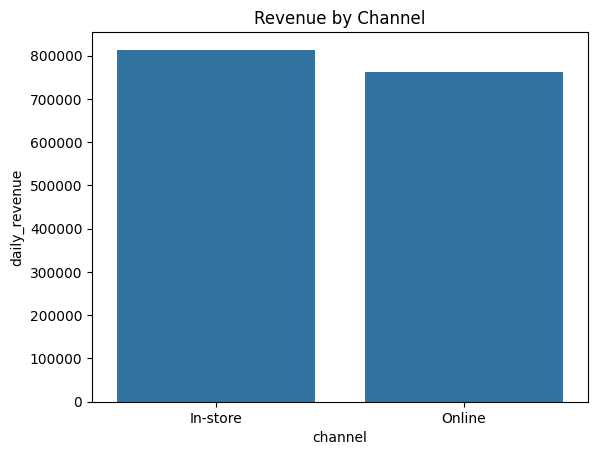

In [17]:
chan_rev = df.groupby('channel')['daily_revenue'].sum().reset_index()
sns.barplot(data=chan_rev, x='channel', y='daily_revenue')
plt.title("Revenue by Channel")
plt.show()


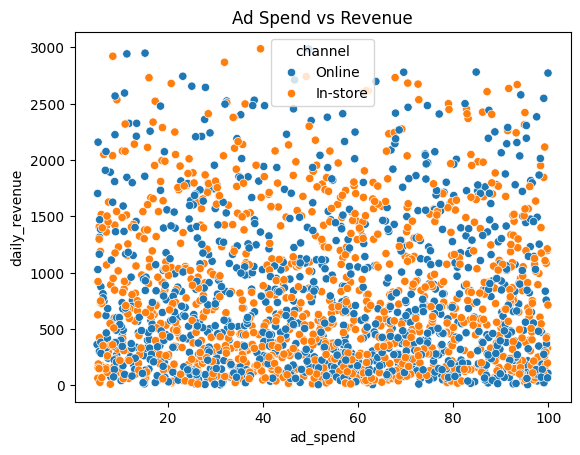

In [18]:
sns.scatterplot(data=df, x='ad_spend', y='daily_revenue', hue='channel')
plt.title("Ad Spend vs Revenue")
plt.show()


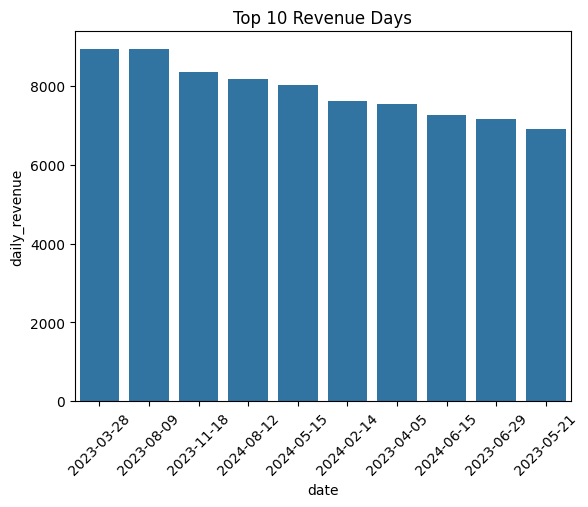

In [20]:
top_days = df.groupby('date')['daily_revenue'].sum().reset_index().nlargest(10, 'daily_revenue')
sns.barplot(data=top_days, x='date', y='daily_revenue')
plt.xticks(rotation=45)
plt.title("Top 10 Revenue Days")
plt.show()


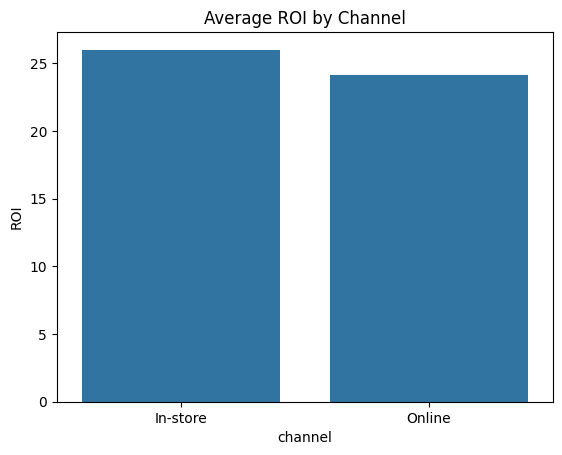

In [21]:
df['ROI'] = df['daily_revenue'] / df['ad_spend'].replace(0, 1)  # avoid divide by zero
roi = df.groupby('channel')['ROI'].mean().reset_index()

sns.barplot(data=roi, x='channel', y='ROI')
plt.title("Average ROI by Channel")
plt.show()


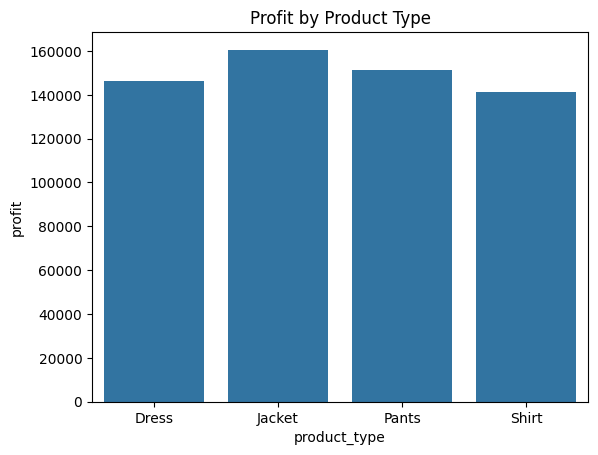

In [22]:
df['profit'] = df['daily_revenue'] - (df['units_sold'] * df['cost'])
prod_profit = df.groupby('product_type')['profit'].sum().reset_index()

sns.barplot(data=prod_profit, x='product_type', y='profit')
plt.title("Profit by Product Type")
plt.show()


In [24]:
df.to_excel('/content/01KA3ZF3978EEZWA02T8AAMEY3.xlsx',index=False)
from google.colab import files
files.download('/content/01KA3ZF3978EEZWA02T8AAMEY3.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>